# IMPORTS + LOAD DATA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

df = pd.read_csv("C:\\Users\\vaddi\\OneDrive\\Desktop\\datasets\\train_u6lujuX_CVtuZ9i (1).csv") 
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# DATA CLEANING

In [5]:
# 1. Target
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

# 2. Missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df.drop('Loan_ID', axis=1, inplace=True)

df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# FEATURE ENGINEERING

In [11]:

df['Dependents'] = df['Dependents'].fillna('0') 
df['Dependents'] = df['Dependents'].astype(str).str.replace('+', '') 
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce') 
df['Dependents'].fillna(0, inplace=True) 
df['Dependents'] = df['Dependents'].astype(int)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['IncomePerPerson'] = df['TotalIncome'] / (df['Dependents'] + 1) 
df['LoanAmount_Log'] = np.log(df['LoanAmount'] + 1)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['Income_Loan_Ratio'] = df['TotalIncome'] / (df['LoanAmount'] + 1) 

print("Features created successfully!")
df[['Dependents', 'TotalIncome', 'IncomePerPerson']].head()

Features created successfully!


,Dependents,TotalIncome,IncomePerPerson
0,0,5849.0,5849.0
1,1,6091.0,3045.5
2,0,3000.0,3000.0
3,0,4941.0,4941.0
4,0,6000.0,6000.0


# TRAIN-TEST SPLIT

In [12]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
            'TotalIncome', 'IncomePerPerson', 'LoanAmount_Log', 'EMI', 'Income_Loan_Ratio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (491, 16)
Test shape: (123, 16)


#  PIPELINE + XGBOOST GRIDSEARCH

In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

xgb = XGBClassifier(scale_pos_weight=1.5, random_state=42, use_label_encoder=False, eval_metric='logloss')

pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', xgb)])

param_grid = {
    'classifier__n_estimators': [400],
    'classifier__max_depth': [4, 5],
    'classifier__learning_rate': [0.01, 0.05]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 400}
Best CV Accuracy: 0.7923


# TEST ACCURACY + REPORT

In [14]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("="*40)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("="*40)
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8618
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



# FEATURE IMPORTANCE GRAPH

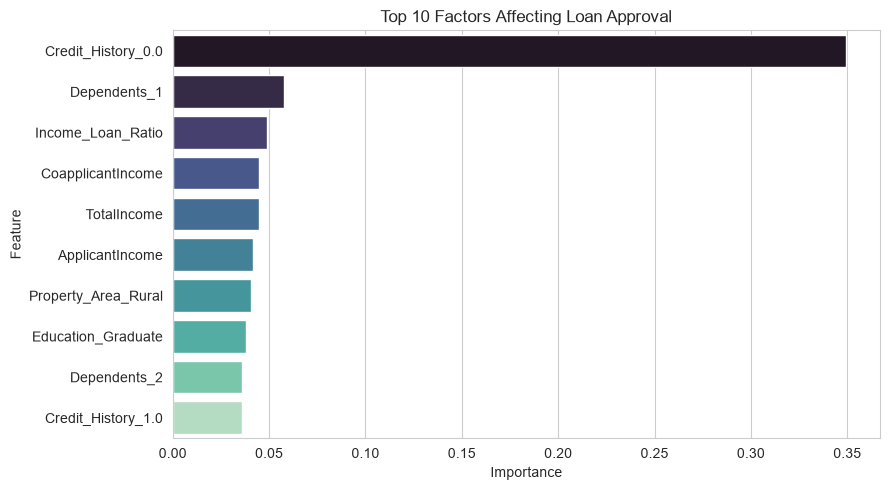

In [15]:
xgb_best = best_model.named_steps['classifier']
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_feature_names)

feature_imp = pd.DataFrame({'Feature': all_features, 'Importance': xgb_best.feature_importances_})
feature_imp = feature_imp.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(x='Importance', y='Feature', data=feature_imp, hue='Feature', palette='mako', legend=False)
plt.title('Top 10 Factors Affecting Loan Approval')
plt.tight_layout()
plt.show()

In [17]:
import joblib
joblib.dump(best_model, 'best_loan_model.pkl')
print("Model Saved Successfully as best_loan_model.pkl")

Model Saved Successfully as best_loan_model.pkl
